In [13]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

# ======================
# Load all saved results
# ======================
log_res = joblib.load("logistic_results.pkl")
rf_res = joblib.load("rf_results.pkl")
svm_res = joblib.load("svm_results.pkl")

results = [log_res, rf_res, svm_res]
results_df = pd.DataFrame(results)
results_df



,Model,Accuracy,Precision,Recall,F1,ConfusionMatrix
0,Logistic Regression,0.542448,0.941396,0.542448,0.673344,"[[56, 7, 8], [1015, 2361, 977], [24, 44, 43]]"
1,Random Forest,0.981257,0.981677,0.981257,0.981229,"[[4319, 28, 6], [29, 82, 0], [10, 12, 49]]"
2,SVM,0.802426,0.953450,0.802426,0.862571,"[[45, 13, 13], [240, 3525, 588], [13, 29, 69]]"


In [14]:
print("Model Performance Comparison:\n")
display(results_df[['Model','Accuracy','Precision','Recall','F1']])




Model Performance Comparison:



,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.542448,0.941396,0.542448,0.673344
1,Random Forest,0.981257,0.981677,0.981257,0.981229
2,SVM,0.802426,0.953450,0.802426,0.862571


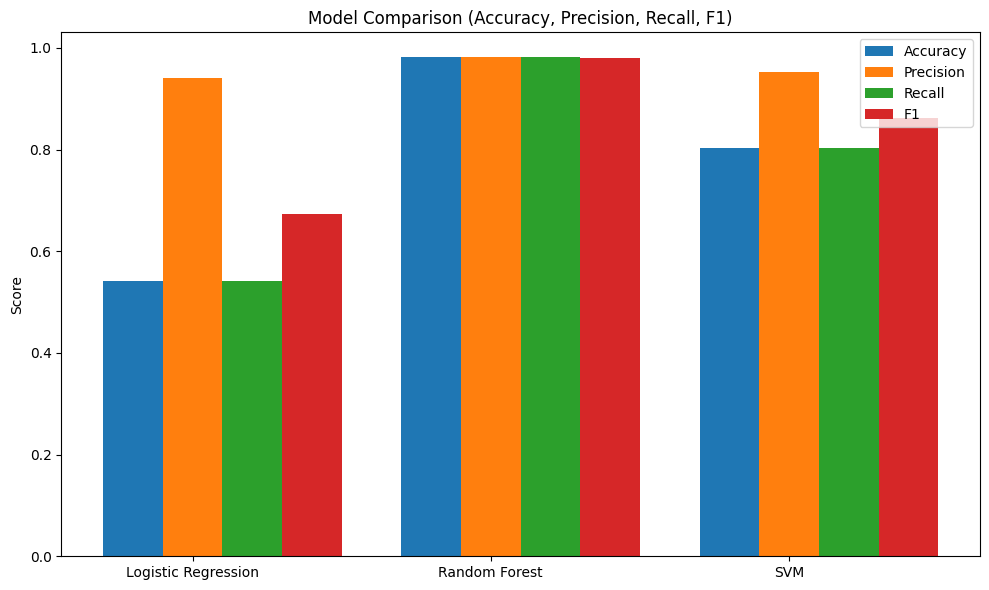

In [15]:
plt.figure(figsize=(10,6))
x = range(len(results_df))
bar_width = 0.2

plt.bar([i - bar_width for i in x], results_df['Accuracy'], width=bar_width, label='Accuracy')
plt.bar(x, results_df['Precision'], width=bar_width, label='Precision')
plt.bar([i + bar_width for i in x], results_df['Recall'], width=bar_width, label='Recall')
plt.bar([i + 2*bar_width for i in x], results_df['F1'], width=bar_width, label='F1')

plt.xticks(x, results_df['Model'])
plt.ylabel('Score')
plt.title('Model Comparison (Accuracy, Precision, Recall, F1)')
plt.legend()
plt.tight_layout()
plt.show()


In [16]:
best_model = results_df.loc[results_df['F1'].idxmax()]
print("\n🏆 Best Model Based on F1-Score:")
print(best_model)



🏆 Best Model Based on F1-Score:
Model                                           Random Forest
Accuracy                                             0.981257
Precision                                            0.981677
Recall                                               0.981257
F1                                                   0.981229
ConfusionMatrix    [[4319, 28, 6], [29, 82, 0], [10, 12, 49]]
Name: 1, dtype: object


📊 Model Performance Comparison:



,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression (Tuned - RSCV),0.663,0.950,0.663,0.767
1,SVM (Tuned - HalvingGridSearchCV),0.944,0.958,0.944,0.950
2,Random Forest,0.981,0.982,0.981,0.981


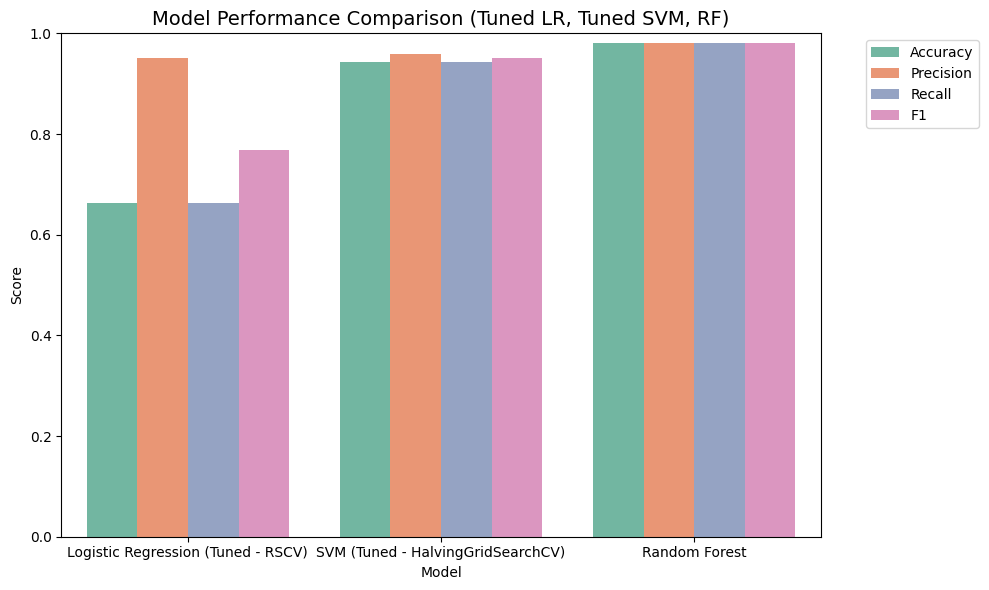

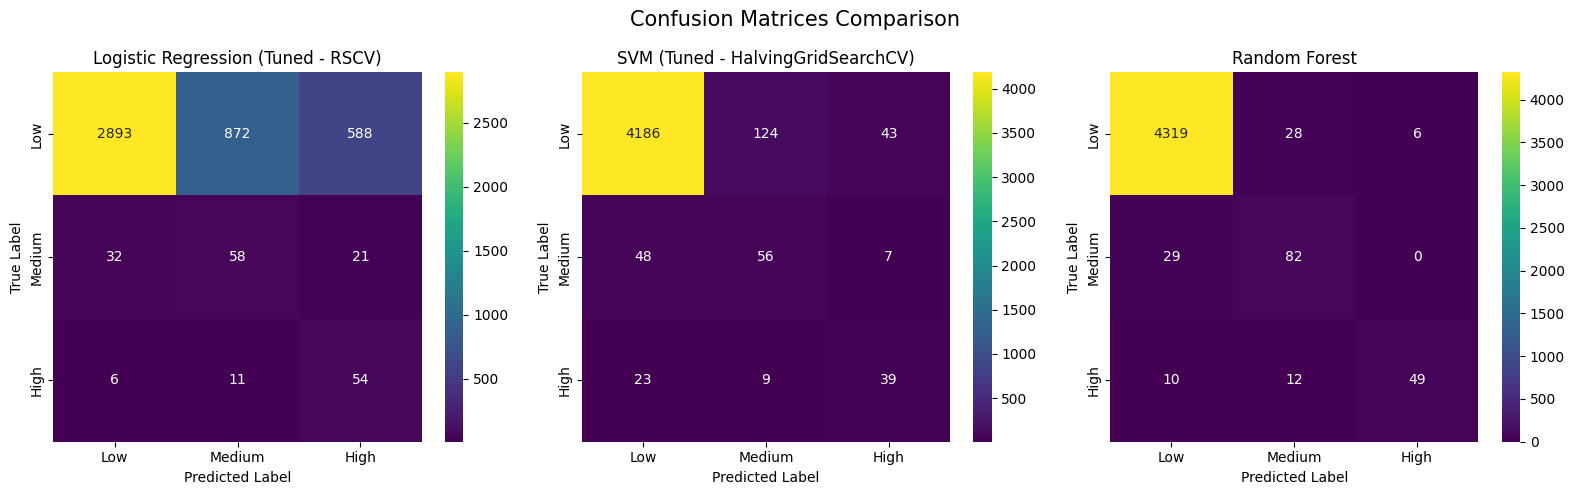

In [17]:

import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


lr_results = joblib.load("lr_tuned_results.pkl")
svm_results = joblib.load("svm_tuned_results.pkl")
rf_results = joblib.load("rf_results.pkl")  # baseline RF file


results_df = pd.DataFrame([
    lr_results,
    svm_results,
    rf_results
])[["Model", "Accuracy", "Precision", "Recall", "F1"]]

# ==============================
# 🧹 Clean Data
# ==============================

# Convert all numeric columns safely
for col in ["Accuracy", "Precision", "Recall", "F1"]:
    results_df[col] = pd.to_numeric(results_df[col], errors='coerce')

# Replace NaN (if any) with 0
results_df.fillna(0, inplace=True)



print("📊 Model Performance Comparison:\n")

display(
    results_df.style
    .background_gradient(cmap="YlGnBu", subset=["Accuracy", "Precision", "Recall", "F1"])
    .format({c: lambda x: f"{x:.3f}" for c in ["Accuracy", "Precision", "Recall", "F1"]})
)


plt.figure(figsize=(10, 6))
results_df_melted = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

sns.barplot(data=results_df_melted, x="Model", y="Score", hue="Metric", palette="Set2")
plt.title("Model Performance Comparison (Tuned LR, Tuned SVM, RF)", fontsize=14)
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 3, figsize=(16, 5))

conf_mats = [
    (lr_results["Model"], lr_results["ConfusionMatrix"]),
    (svm_results["Model"], svm_results["ConfusionMatrix"]),
    (rf_results["Model"], rf_results["ConfusionMatrix"])
]

for ax, (title, cm) in zip(axes, conf_mats):
    sns.heatmap(
        cm, annot=True, fmt='d', cmap="viridis",
        xticklabels=['Low', 'Medium', 'High'],
        yticklabels=['Low', 'Medium', 'High'],
        ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

plt.suptitle("Confusion Matrices Comparison", fontsize=15)
plt.tight_layout()
plt.show()


In [18]:
best_model = results_df.loc[results_df['Accuracy'].idxmax()]
print("\n🏆 Best Model Based on Accuracy:")
print(best_model)


🏆 Best Model Based on Accuracy:
Model        Random Forest
Accuracy          0.981257
Precision         0.981677
Recall            0.981257
F1                0.981229
Name: 2, dtype: object
